In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X=np.array([[0,0],[0,1],[1,0],[1,1]],dtype=float)

In [4]:
y=np.array([[0],[1],[1],[0]],dtype=float)

In [5]:
print("Input Data: ")
print(X)

Input Data: 
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]


In [6]:
input_size = 2
hidden_size = 4
output_size = 1

In [7]:
print("Network Architecture: ")
print(input_size,"Input Neurons")
print(hidden_size,"Hidden Neurons")
print(output_size,"Output Neuron")


Network Architecture: 
2 Input Neurons
4 Hidden Neurons
1 Output Neuron


In [8]:
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size)*0.5
b1=np.zeros((1,hidden_size))

In [9]:
W2= np.random.randn(hidden_size, output_size)*0.5
b2=np.zeros((1,output_size))

In [10]:
print("Initial Weights and Biases: ")
print("\nW1: ",W1)
print("\nb1: ",b1)
print("\nW2: ",W2)
print("\nb2: ",b2)

Initial Weights and Biases: 

W1:  [[ 0.24835708 -0.06913215  0.32384427  0.76151493]
 [-0.11707669 -0.11706848  0.78960641  0.38371736]]

b1:  [[0. 0. 0. 0.]]

W2:  [[-0.23473719]
 [ 0.27128002]
 [-0.23170885]
 [-0.23286488]]

b2:  [[0.]]


In [11]:
def sigmoid(z):
    return 1/(1+np.exp(-np.clip(z, -500, 500)))

In [ ]:
def step_function(x):
    if x >= 0:
        return 1
    else:
        return 0


In [12]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss= -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

In [13]:
def forward_propagation(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    return Z1,A1,Z2,A2

In [14]:
Z1, A1, Z2, A2 = forward_propagation(X, W1, b1, W2, b2)
print("Initial Predictions: ")
print(A2)
initial_loss = binary_cross_entropy(y, A2)
print("Initial Loss: ", initial_loss)

Initial Predictions: 
[[0.44669943]
 [0.43029337]
 [0.42699871]
 [0.41263144]]
Initial Loss:  0.7045547507201497


In [15]:
learning_rate = 1
epochs = 10000
loss_history = []

In [16]:
for epoch in range(epochs):
    indices=np.random.permutation(len(X))
    epoch_loss = 0
    for i in indices:
        X_sample = X[i:i+1]
        y_sample = y[i:i+1]
        Z1=np.dot(X_sample, W1) + b1
        A1=sigmoid(Z1)
        Z2=np.dot(A1, W2) + b2
        A2=sigmoid(Z2)

        loss = binary_cross_entropy(y_sample, A2)
        epoch_loss += loss

        dZ2 = A2 - y_sample
        dW2 = np.dot(A1.T, dZ2)
        db2 = dZ2

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * A1 * (1 - A1)
        dW1 = np.dot(X_sample.T, dZ1)
        db1 = dZ1

        W2 =W2-learning_rate * dW2
        b2 =b2-learning_rate * db2
        W1 =W1-learning_rate * dW1
        b1 =b1-learning_rate * db1

        epoch_loss= epoch_loss / len(X)
        loss_history.append(epoch_loss)
        if epoch % 1000 == 0:
            print(f"Epoch {epoch}, Loss: {epoch_loss}")







Epoch 0, Loss: 0.14796347255418058
Epoch 0, Loss: 0.41533176283727363
Epoch 0, Loss: 0.21596203025455363
Epoch 0, Loss: 0.46644038566244217
Epoch 1000, Loss: 0.0016395398654288746
Epoch 1000, Loss: 0.0005050089365173712
Epoch 1000, Loss: 0.0008355639986465354
Epoch 1000, Loss: 0.0009237236181441137
Epoch 2000, Loss: 0.0007075345575301137
Epoch 2000, Loss: 0.0004800469870902516
Epoch 2000, Loss: 0.00015454786187485645
Epoch 2000, Loss: 0.00033925076265562163
Epoch 3000, Loss: 2.0151692383258106e-05
Epoch 3000, Loss: 0.0001949285209226918
Epoch 3000, Loss: 0.00023968680167058955
Epoch 3000, Loss: 0.0005107873794988855
Epoch 4000, Loss: 0.00013948918617342414
Epoch 4000, Loss: 4.8848182669794456e-05
Epoch 4000, Loss: 0.0003422638899668213
Epoch 4000, Loss: 0.00022441310783374835
Epoch 5000, Loss: 0.00010976123927342258
Epoch 5000, Loss: 0.0001365943988319431
Epoch 5000, Loss: 4.473753272456852e-05
Epoch 5000, Loss: 0.00027166744393988703
Epoch 6000, Loss: 9.04432524948278e-05
Epoch 6000, 

In [17]:
Z1, A1, Z2, predictions = forward_propagation(X, W1, b1, W2, b2)

In [18]:
print("\nFinal Predictions: ")
print("Input: ")
print(X)
print("Actual Output: ")
print(y)
print("Predicted Output: ")
print(predictions)


Final Predictions: 
Input: 
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Actual Output: 
[[0.]
 [1.]
 [1.]
 [0.]]
Predicted Output: 
[[1.82791462e-05]
 [9.99788828e-01]
 [9.99788026e-01]
 [5.05947455e-04]]


In [19]:
predicted_classes = (
    predictions >= 0.5
).astype(int)

print("\nPredicted Classes:")
print(predicted_classes)


Predicted Classes:
[[0]
 [1]
 [1]
 [0]]


In [20]:
final_loss = binary_cross_entropy(y, predictions)
print("Final Loss: ", final_loss)

Final Loss:  0.00023688638682761227


In [21]:
accuracy = np.mean(predicted_classes == y)*100
print("Accuracy: ", accuracy ,"%")

Accuracy:  100.0 %


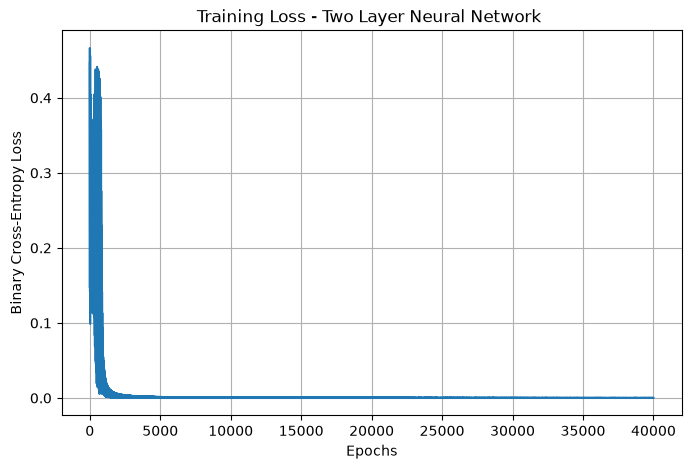

In [22]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss - Two Layer Neural Network ")
plt.grid(True)
plt.show()

In [24]:
print("********************************")
print("Final Network Parameters: ")
print("********************************")
print("\nFinal W1: ")
print(W1)
print("\nFINAL b1: ")
print(b1)
print("\nFinal W2: ")
print(W2)
print("\nFinal b2: ")
print(b2)


********************************
Final Network Parameters: 
********************************

Final W1: 
[[-5.94952549 -6.79400165 -8.94164655  4.78708716]
 [-5.8608836  -6.69424672  4.93740641 -8.90601798]]

FINAL b1: 
[[ 1.17409256  1.69747595 -1.23084609 -1.10570779]]

Final W2: 
[[-5.9390352 ]
 [-7.74987089]
 [16.73597873]
 [16.73272324]]

Final b2: 
[[-7.76661839]]


In [26]:
print("\n*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*")
print("TRAINING SUMMARY")
print("*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*")

print("Architecture:", input_size, "->", hidden_size, "->", output_size)
print("Learning Rate:", learning_rate)
print("Epochs:", epochs)
print("Final Loss:", final_loss)
print("Final Accuracy:", accuracy, "%")

print("\nThe neural network has successfully learned XOR.")


*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
TRAINING SUMMARY
*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Architecture: 2 -> 4 -> 1
Learning Rate: 1
Epochs: 10000
Final Loss: 0.00023688638682761227
Final Accuracy: 100.0 %

The neural network has successfully learned XOR.
